## Objective
To perform exploratory data analysis on Delhi weather and air quality data to understand pollution patterns and their relationship with weather parameters.


In [ ]:
# 1) Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# 2) Load Dataset

df = pd.read_excel('/content/delhi-weather-aqi-2025.xlsx')

In [ ]:
''' 3) Initial Data Preview
        a) Head
'''
df.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [ ]:
''' 3) Initial Data Preview
        b) Tail
'''
df.tail()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
52555,31/12/2025,19:00,IGI Airport,28.5562,77.1,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.1,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.1,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.1,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2
52559,31/12/2025,23:00,IGI Airport,28.5562,77.1,13.3,95,985.1,6.5,Partly cloudy,WMO Code 2,208,142.0,142.0,1354,61.5


In [ ]:
# 4) Dataset column names
df.columns

Index(['date_ist', 'time_ist', 'location', 'lat', 'lon', 'temp_c', 'humidity',
       'pressure_mb', 'windspeed_kph', 'condition_text', 'description',
       'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'],
      dtype='object')

In [ ]:
# 5) Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


In [ ]:
# 6) Statistical Summary(Before cleaning data)
df.describe(include=[np.number])


,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


In [ ]:
# 7) Dataset Shape
df.shape

(52560, 16)

In [ ]:
# 8) Drop Unnecessary Column
df.drop(columns=['description'], inplace=True)


In [ ]:
df.drop(columns=['time_ist'], inplace=True)

In [ ]:
# 9) Check Missing Values
df.isnull().sum()


,0
date_ist,0
location,0
lat,0
lon,0
temp_c,0
humidity,0
pressure_mb,0
windspeed_kph,0
condition_text,0
aqi_index,0


In [ ]:
# 10) Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# 11) Convert Date Column (Correct Format)
df['date_ist'] = pd.to_datetime(df['date_ist'], dayfirst=True)


In [ ]:
# 12) Statistical Summary(After cleaning data)
df.describe(include=[np.number])

,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


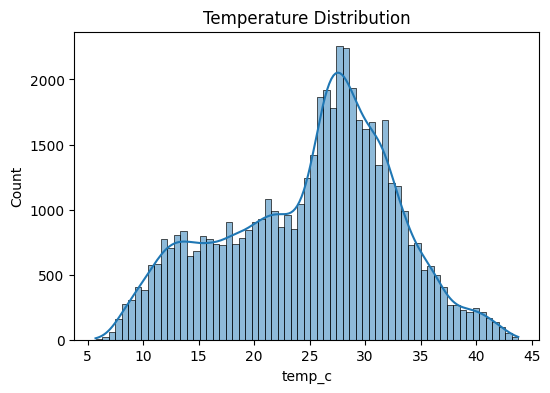

In [ ]:
# 13) Histogram – Temperature
plt.figure(figsize=(6,4))
sns.histplot(df['temp_c'], kde=True)
plt.title('Temperature Distribution')
plt.show()


**Insight:** PM2.5 distribution is right-skewed, indicating frequent high pollution events with occasional extreme spikes.


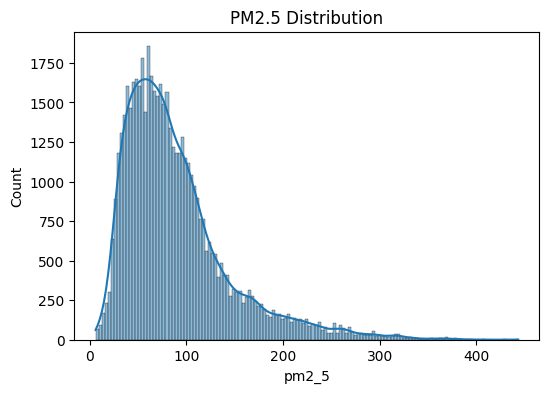

In [ ]:
# 14) Histogram – PM2.5
plt.figure(figsize=(6,4))
sns.histplot(df['pm2_5'], kde=True)
plt.title('PM2.5 Distribution')
plt.show()


**Insight:** Temperature shows seasonal variation with a concentration around mid-20s, reflecting Delhi’s climate pattern.


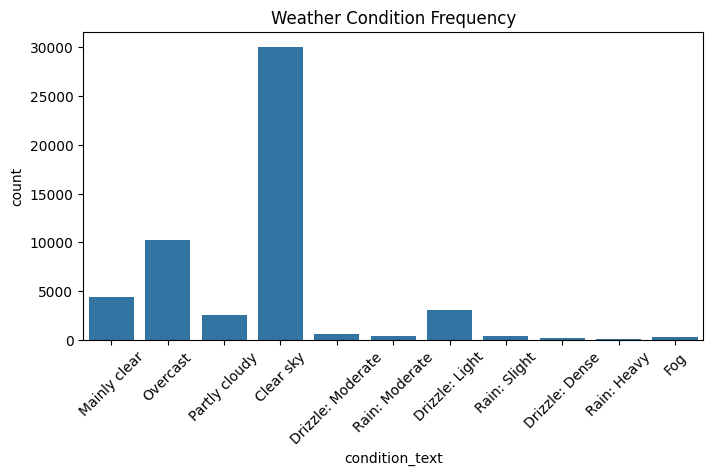

In [ ]:
# 15) Count Plot – Weather Condition
plt.figure(figsize=(8,4))
sns.countplot(x='condition_text', data=df)
plt.xticks(rotation=45)
plt.title('Weather Condition Frequency')
plt.show()


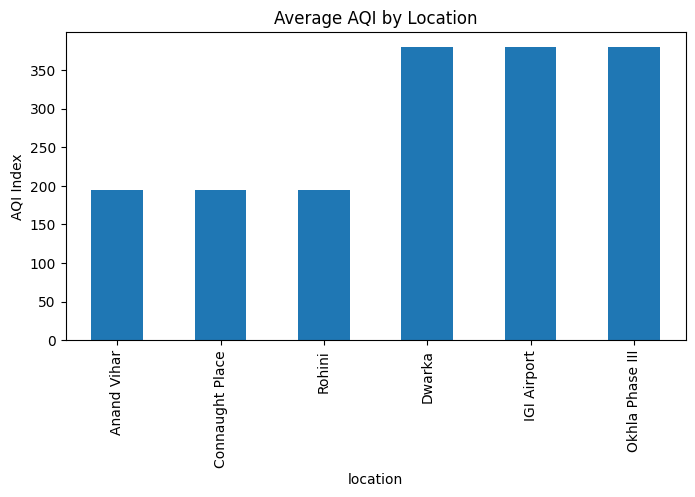

In [ ]:
# 16) Location-wise Average AQI
plt.figure(figsize=(8,4))
df.groupby('location')['aqi_index'].mean().sort_values().plot(kind='bar')
plt.title('Average AQI by Location')
plt.ylabel('AQI Index')
plt.show()


In [ ]:
# 17) Final Dataset Verification and Final Data Preview
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_ist        52560 non-null  datetime64[ns]
 1   location        52560 non-null  object        
 2   lat             52560 non-null  float64       
 3   lon             52560 non-null  float64       
 4   temp_c          52560 non-null  float64       
 5   humidity        52560 non-null  int64         
 6   pressure_mb     52560 non-null  float64       
 7   windspeed_kph   52560 non-null  float64       
 8   condition_text  52560 non-null  object        
 9   aqi_index       52560 non-null  int64         
 10  pm2_5           52560 non-null  float64       
 11  pm10            52560 non-null  float64       
 12  co              52560 non-null  int64         
 13  no2             52560 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(3), object(2)


,date_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,aqi_index,pm2_5,pm10,co,no2
0,2025-01-01,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,197,185.8,188.6,1907,56.7
1,2025-01-01,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,198,174.6,177.4,1669,44.8
2,2025-01-01,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,199,164.4,166.7,1493,34.6
3,2025-01-01,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,200,156.5,158.8,1401,26.7
4,2025-01-01,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,200,149.5,151.8,1372,20.6


## Conclusion
The analysis shows that particulate matter (PM2.5 and PM10) is the dominant contributor to air quality in Delhi, while weather parameters such as temperature, humidity, and wind speed exhibit secondary influence. Pollution levels vary significantly across locations.
